In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls, minimize

df = pd.read_csv("data.csv", index_col=0)
df

,PSC,JUNTS,ERC,PP,VOX,COMUNS,CUP,ALIANÇA.CAT,Altres candidatures,Cs,Abstenció
1980,0.138185,0.171275,0.054873,0.014556,0.000000,0.115557,0.000000,0.000000,0.117144,0.000000,0.388410
1984,0.193811,0.301318,0.028411,0.049647,0.000000,0.035962,0.000000,0.000000,0.031802,0.000000,0.359048
1988,0.177197,0.272179,0.024616,0.031648,0.000000,0.046166,0.000000,0.000000,0.039541,0.000000,0.408652
1992,0.152089,0.255296,0.043962,0.032968,0.000000,0.035913,0.000000,0.000000,0.025621,0.000000,0.454152
1995,0.159822,0.263467,0.061096,0.084246,0.000000,0.062607,0.000000,0.000000,0.005756,0.000000,0.363006
1999,0.227821,0.226843,0.052261,0.057211,0.000000,0.015129,0.000000,0.000000,0.016845,0.000000,0.403890
2003,0.198586,0.196993,0.104874,0.075627,0.000000,0.046480,0.000000,0.000000,0.008517,0.000000,0.368922
2006,0.153722,0.180767,0.080571,0.060980,0.000000,0.054760,0.000000,0.000000,0.013357,0.017425,0.438418
2010,0.111491,0.234199,0.042640,0.075148,0.000000,0.044927,0.000000,0.000000,0.061473,0.020696,0.409426
2012,0.101217,0.215104,0.095984,0.091014,0.000000,0.069380,0.024398,0.000000,0.040548,0.053099,0.309256


In [2]:
df["Dreta espanyola"] = df["PP"] + df["Cs"] + df["VOX"]
df["Dreta catalana"] = df["JUNTS"] + df["ALIANÇA.CAT"]
df["Esquerra catalana"] = df["ERC"] + df["CUP"]
df["Esquerra espanyola"] = df["PSC"] + df["COMUNS"]
df.drop(columns=["PP", "Cs", "VOX", "JUNTS", "ALIANÇA.CAT", "ERC", "CUP", "PSC", "COMUNS"], inplace=True)
df

,Altres candidatures,Abstenció,Dreta espanyola,Dreta catalana,Esquerra catalana,Esquerra espanyola
1980,0.117144,0.388410,0.014556,0.171275,0.054873,0.253742
1984,0.031802,0.359048,0.049647,0.301318,0.028411,0.229773
1988,0.039541,0.408652,0.031648,0.272179,0.024616,0.223363
1992,0.025621,0.454152,0.032968,0.255296,0.043962,0.188002
1995,0.005756,0.363006,0.084246,0.263467,0.061096,0.222429
1999,0.016845,0.403890,0.057211,0.226843,0.052261,0.242950
2003,0.008517,0.368922,0.075627,0.196993,0.104874,0.245066
2006,0.013357,0.438418,0.078405,0.180767,0.080571,0.208482
2010,0.061473,0.409426,0.095844,0.234199,0.042640,0.156418
2012,0.040548,0.309256,0.144113,0.215104,0.120382,0.170597


In [3]:
list(df.columns)

['Altres candidatures',
 'Abstenció',
 'Dreta espanyola',
 'Dreta catalana',
 'Esquerra catalana',
 'Esquerra espanyola']

Stable Markov Chain Model (14 Years, 6 Parties)
Global Transition Matrix (Rows = From Party, Columns = To Party):
                     Altres candidatures  Abstenció  Dreta espanyola  Dreta catalana  Esquerra catalana  Esquerra espanyola
Altres candidatures               0.4620     0.0000           0.1259          0.3898             0.0000              0.0224
Abstenció                         0.0119     0.4374           0.0650          0.2992             0.0000              0.1865
Dreta espanyola                   0.0123     0.2306           0.5434          0.0000             0.1926              0.0211
Dreta catalana                    0.0209     0.3070           0.0509          0.3842             0.1021              0.1348
Esquerra catalana                 0.0027     0.2560           0.1132          0.0000             0.5977              0.0305
Esquerra espanyola                0.0000     0.5167           0.0000          0.0298             0.0000              0.4535


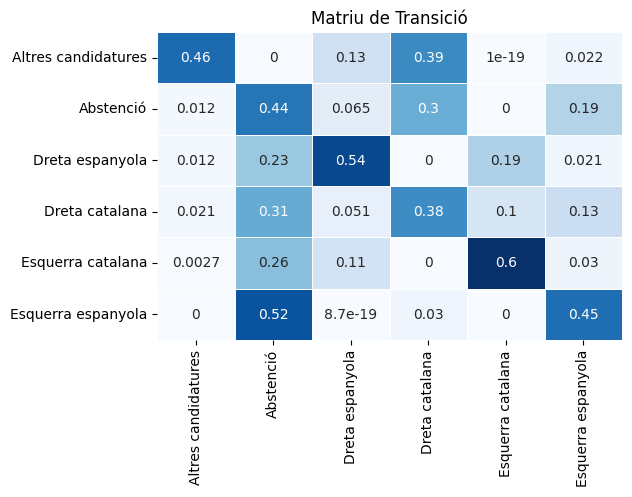

In [4]:
from utils import StableMarkovChain

mc = StableMarkovChain(df)
mc.fit()

print(mc)
mc.plot_transition_matrix()

Altres candidatures    0.019215
Abstenció              0.376483
Dreta espanyola        0.107263
Dreta catalana         0.204286
Esquerra catalana      0.103203
Esquerra espanyola     0.189550
dtype: float64


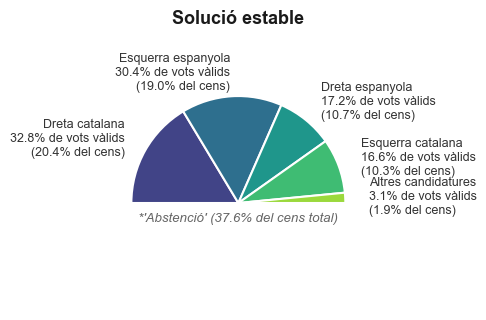

In [5]:
print(mc.get_steady_state())
mc.plot_steady_state()

In [6]:
df = df.iloc[-len(df.columns):]

# Dades numèriques
dades = df.values

# Partits
partits = df.columns
n = len(partits)

print("Partits:", list(partits))

# X_t ≈ P * X_{t+1}
A = dades[1:]   # futur
B = dades[:-1]  # passat

P_llista = []

# Intensitat de la penalització
lambda_transvas = 0.05

for j in range(n):

    b = B[:, j]

    # Funció objectiu
    def objectiu(p):

        # Error quadràtic
        error = np.sum((A @ p - b) ** 2)

        # Penalització dels transvasaments
        mask = np.arange(n) != j

        penalitzacio = lambda_transvas * np.sum(p[mask] ** 2)

        return error + penalitzacio

    # Valor inicial
    p0 = np.ones(n) / n

    # Restricció: p_i >= 0
    bounds = [(0, None)] * n

    # Optimització
    resultat = minimize(
        objectiu,
        p0,
        bounds=bounds,
        method='L-BFGS-B'
    )

    p_opt = resultat.x

    # Normalitzar perquè sumi 1
    if p_opt.sum() > 0:
        p_opt = p_opt / p_opt.sum()

    P_llista.append(p_opt)

# Construcció matriu final
P_est = np.array(P_llista).T

df_P_final = pd.DataFrame(
    P_est,
    index=partits,
    columns=partits
)

print("\nMatriu de Transició amb fidelitat partidista:")
print(df_P_final.round(3).to_string())

Partits: ['Altres candidatures', 'Abstenció', 'Dreta espanyola', 'Dreta catalana', 'Esquerra catalana', 'Esquerra espanyola']

Matriu de Transició amb fidelitat partidista:
                     Altres candidatures  Abstenció  Dreta espanyola  Dreta catalana  Esquerra catalana  Esquerra espanyola
Altres candidatures                0.960      0.032            0.000           0.014              0.000               0.004
Abstenció                          0.000      0.403            0.238           0.033              0.188               0.023
Dreta espanyola                    0.023      0.141            0.612           0.011              0.000               0.025
Dreta catalana                     0.017      0.259            0.000           0.882              0.000               0.002
Esquerra catalana                  0.000      0.000            0.149           0.060              0.812               0.049
Esquerra espanyola                 0.000      0.165            0.000           0.00

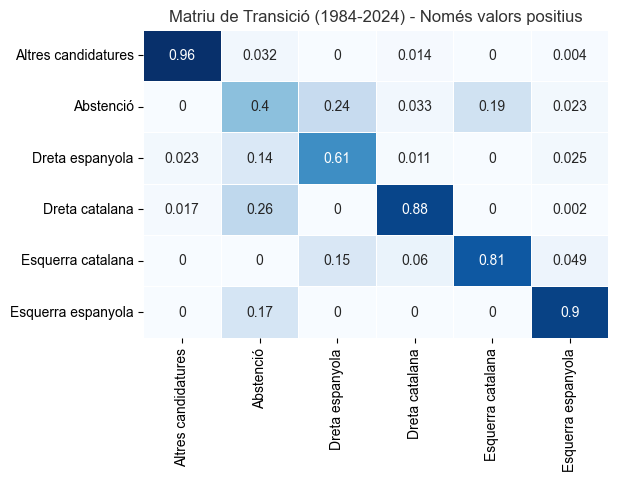

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
sns.heatmap(df_P_final.round(3), annot=True, cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Matriu de Transició (1984-2024) - Només valors positius")
plt.show()

In [8]:
import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(df_P_final)

# Trobar l'índex de l'autovalor més proper a 1
idx = np.argmin(np.abs(eigenvalues - 1))

# Extreure el vector i normalitzar (suma = 1)
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

partits = list(df_P_final.columns)
for p, v in zip(partits, pi):
    print(f"{p:10s}: {v:.4f}")

###### COMPROVACIÓ DE LA DISTRIBUCIÓ ESTACIONÀRIA ######
print("\nComprovació de la distribució estacionària:")
print(np.allclose(df_P_final @ pi, pi))  # Ha de donar True
print(pi.sum())                    # Ha de donar 1.0

Altres candidatures: 0.1987
Abstenció : 0.1079
Dreta espanyola: 0.0696
Dreta catalana: 0.2680
Esquerra catalana: 0.1858
Esquerra espanyola: 0.1700

Comprovació de la distribució estacionària:
True
1.0
